# **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

DBSCAN is a **density-based clustering algorithm** widely used in machine learning for identifying clusters of varying shapes while detecting outliers. Unlike *K-Means* or *Hierarchical Clustering*, DBSCAN does not require predefining the number of clusters and works well with noisy data.

---

## **1. Key Concepts of DBSCAN**
### **A. Core Components**
1. **Epsilon (ε) - Neighborhood Radius**  
   - Defines the maximum distance between two points to be considered neighbors.  
   - A smaller ε means tighter clusters, while a larger ε merges more points.

2. **MinPts (Minimum Points)**  
   - The minimum number of points required within ε to form a **dense region**.  
   - A higher MinPts makes the algorithm more robust to noise but may miss small clusters.

3. **Core Point**  
   - A point is a **core point** if it has at least `MinPts` within its ε-neighborhood (including itself).

4. **Border Point**  
   - A point that has fewer than `MinPts` in its ε-neighborhood but is reachable from a core point.

5. **Noise Point (Outlier)**  
   - A point that is neither a core nor a border point (does not belong to any cluster).

---

### **B. Reachability & Cluster Formation**
- **Directly Density-Reachable**:  
  A point `q` is directly density-reachable from `p` if `q` is within ε-distance of `p` and `p` is a core point.  
- **Density-Reachable**:  
  A point `q` is density-reachable from `p` if there is a chain of core points connecting them.  
- **Density-Connected**:  
  Two points `p` and `q` are density-connected if a third point `o` exists from which both are density-reachable.

**Cluster Definition**:  
A cluster is a set of **density-connected** points, along with all points reachable from them.

---

## **2. How DBSCAN Works (Step-by-Step)**
1. **Randomly pick an unvisited point** `p`.  
2. **Check ε-neighborhood**:  
   - If `p` has ≥ `MinPts` neighbors → **Core point** → Form a new cluster.  
   - Else → Mark as **noise** (may be reassigned later).  
3. **Expand the cluster**:  
   - For each neighbor `q` of `p`, check if it’s a core point and recursively add all reachable points.  
4. **Repeat** until all points are visited.  

---

## **3. Advantages of DBSCAN**
✅ **No Need to Specify Number of Clusters** (Unlike K-Means).  
✅ **Handles Arbitrarily Shaped Clusters** (Unlike centroid-based methods).  
✅ **Robust to Outliers** (Explicitly labels noise points).  
✅ **Works Well with Spatial Data** (e.g., GPS, image segmentation).  

---

## **4. Limitations of DBSCAN**
❌ **Sensitive to ε and MinPts** (Poor parameter choice leads to bad clustering).  
❌ **Struggles with Varying Densities** (If clusters have different densities, may fail).  
❌ **Not Fully Deterministic** (Border points may be assigned to different clusters in different runs).  
❌ **Slower Than K-Means** (O(n log n) with spatial indexing, but O(n²) in worst case).  

---

## **5. Parameter Selection Tips**
- **ε (eps)**:  
  - Use the **k-distance graph** (plot sorted distances of each point to its k-th nearest neighbor, where `k = MinPts`).  
  - The "elbow point" in the graph suggests a good ε.  
- **MinPts**:  
  - Rule of thumb: `MinPts ≥ D + 1` (where `D` = data dimensionality).  
  - For noisy data, higher `MinPts` (e.g., 10-20) helps.  

---

## **6. When to Use DBSCAN?**
✔ **Data with Noise/Outliers** (e.g., fraud detection).  
✔ **Irregular Cluster Shapes** (e.g., geographical data).  
✔ **Unknown Number of Clusters** (Exploratory data analysis).  

🚫 **Avoid When:**  
- Clusters have significantly different densities.  
- High-dimensional data (curse of dimensionality affects distance metrics).  

---

## **7. Practical Implementation (Python Example)**
```python
from sklearn.cluster import DBSCAN
import numpy as np

# Sample Data
X = np.array([[1, 2], [2, 2], [2, 3], [8, 7], [8, 8], [25, 80]])

# DBSCAN Model
dbscan = DBSCAN(eps=3, min_samples=2)
labels = dbscan.fit_predict(X)

print("Cluster Labels:", labels)  # -1 = Noise
```

**Output Interpretation**:  
- `0, 1, 2`: Points in Cluster 0.  
- `3, 4`: Points in Cluster 1.  
- `-1`: Noise (outlier).  

---

## **8. Extensions & Variants**
- **HDBSCAN**: Improves density-varying clusters using hierarchical clustering.  
- **OPTICS**: Replaces ε with a reachability plot for better parameter flexibility.  

---

## **9. Summary**
- **DBSCAN** is a powerful clustering method for **non-linear structures** and **noisy data**.  
- Key parameters: **ε (eps)** and **MinPts**.  
- Works best when clusters are **dense** and **well-separated**.  
- Alternative: Use **HDBSCAN** for varying densities.  

---

### **Further Reading**
- [Original DBSCAN Paper (Ester et al., 1996)](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf)  
- [Scikit-learn DBSCAN Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)  


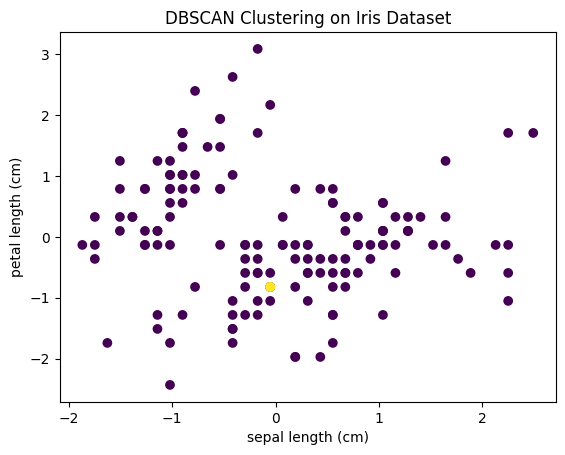

In [31]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 

# load the iris dataset
iris = load_iris()
X = iris.data

# standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# fit the model
model = DBSCAN(eps=0.1, min_samples=2)
model.fit(X)

# plot the results
plt.scatter(X[:, 0], X[:, 1], c=model.labels_)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("DBSCAN Clustering on Iris Dataset")
plt.show()

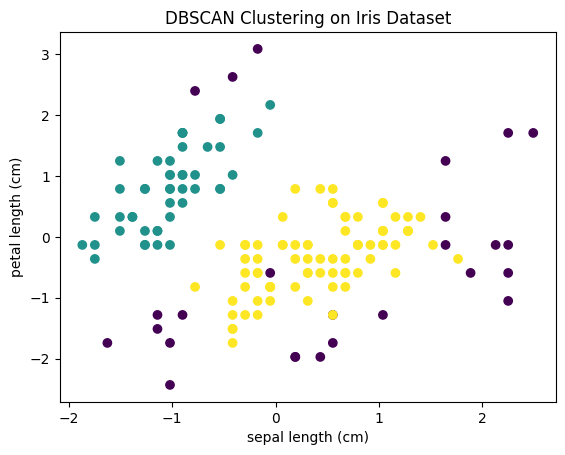

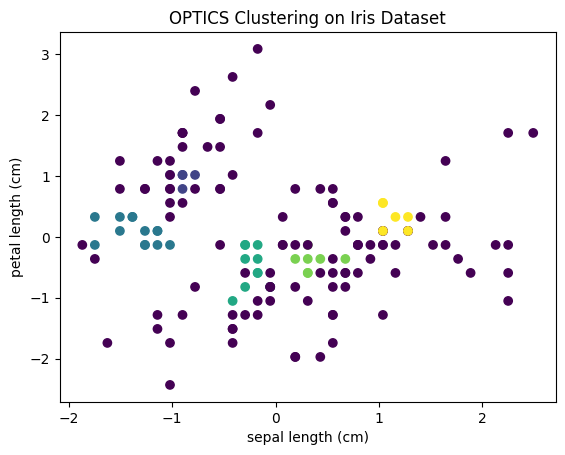

In [32]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN,OPTICS
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# load the dataset 
iris = load_iris()
X = iris.data

# standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create DBSCAN Object 
dbscan = DBSCAN(eps=0.6, min_samples=5)

# Create OPTICS Object 
optics = OPTICS(min_samples=5,xi=0.05)

# Train the models 
dbscan.fit(X)
optics.fit(X)

# Plot the data-points with color coded clusters for dbscan
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("DBSCAN Clustering on Iris Dataset")
plt.show()
# Plot the data-points with color coded clusters for OPTICS 
plt.scatter(X[:,0],X[:,1],c=optics.labels_)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("OPTICS Clustering on Iris Dataset")
plt.show()

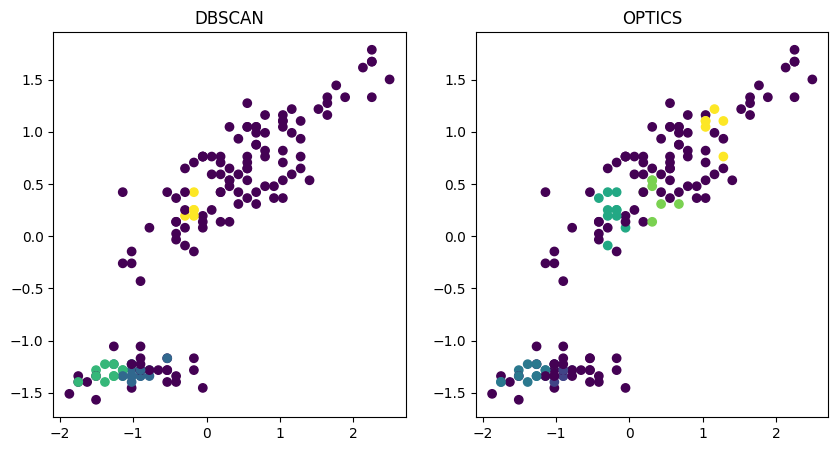

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN,OPTICS
from sklearn.preprocessing import StandardScaler

df = sns.load_dataset('iris')
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

X = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

optics = OPTICS(min_samples=5)
optics_labels = optics.fit_predict(X)

# plotting the both model clusters 
fig , ax = plt.subplots(1,2,figsize=(10,5))

# dbscan 
ax[0].scatter(X[:,0],X[:,2],c=dbscan_labels)
ax[0].set_title('DBSCAN')

# optics plot 
ax[1].scatter(X[:,0],X[:,2],c=optics_labels)
ax[1].set_title('OPTICS')

plt.show()

# Hyperparameters for DBSCAN
A k-distance plot, also known as a k-distance graph, is a useful tool for determining the appropriate epsilon value when using the DBSCAN algorithm. The idea behind a k-distance plot is to plot the distance to the kth nearest neighbor for each point, sort the distances, and then look for the "elbow" or "knee" in the plot. The value of epsilon can be chosen as the y-coordinate of this "elbow" point.

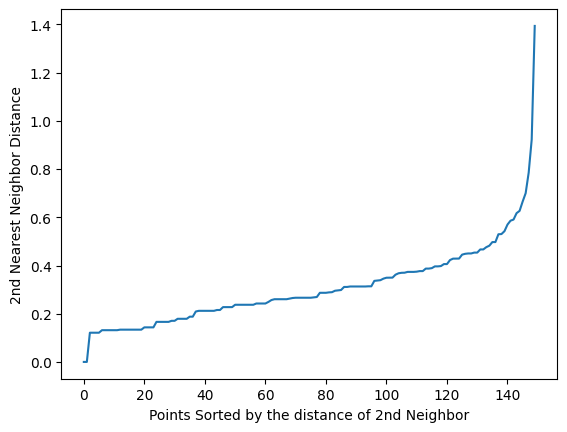

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

df = sns.load_dataset('iris')

features = df[['sepal_length','sepal_width','petal_length','petal_width']].values
features = StandardScaler().fit_transform(features)

neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(features)

distances , indices = nbrs.kneighbors(features)

distances = np.sort(distances,axis=0)
distances = distances[:,1]

plt.plot(distances)
plt.xlabel('Points Sorted by the distance of 2nd Neighbor')
plt.ylabel('2nd Nearest Neighbor Distance')
plt.show()

# KneeLocator

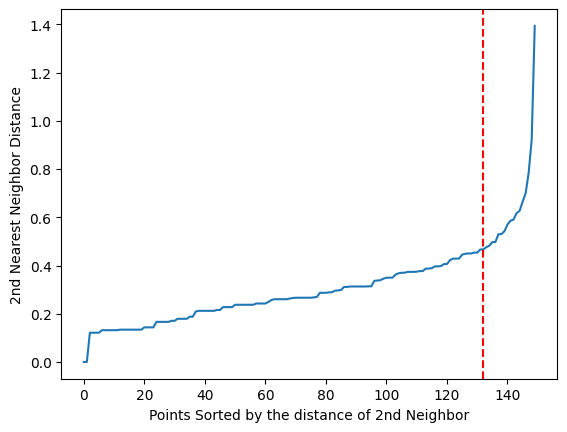

Knee point is at 132 with a distance of 0.46662903814690937
 Suggested value of eps for DBSCAN: 0.46662903814690937


In [23]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# load the dataset
df = sns.load_dataset('iris')
features = df[['sepal_length','sepal_width','petal_length','petal_width']].values 

features = StandardScaler().fit_transform(features)

# Find the nearest neighbors
neigh = NearestNeighbors(n_neighbors=3)
nbrs = neigh.fit(features)
distances, indices = nbrs.kneighbors(features)

distances = np.sort(distances,axis=0)
distances = distances[:,1]



kl = KneeLocator(
    range(len(distances)),  # X-axis: Point indices
    distances,  # Y-axis: 2nd-neighbor distances
    curve='convex',  # Shape of the curve (outward bend)
    direction='increasing'  # Distances increase as we move right
)

# Plot the graph
plt.plot(distances)
plt.xlabel('Points Sorted by the distance of 2nd Neighbor')
plt.ylabel('2nd Nearest Neighbor Distance')
plt.axvline(x=kl.elbow, color='r', linestyle='--')
plt.show()
print(f"Knee point is at {kl.elbow} with a distance of {distances[kl.elbow]}\n Suggested value of eps for DBSCAN: {distances[kl.elbow]}")

# **How to find the best num of MinPts**
The choice of minPts parameter in DBSCAN is less critical compared to eps but it also affects the results of DBSCAN. The minPts parameter specifies the minimum number of points required to form a dense region (or a cluster).

A common heuristic for selecting minPts in DBSCAN is to set it to 2dim, where dim is the dimensionality of your dataset. For example, if you're clustering data with 4 features (like in the iris dataset), you could start with minPts = 24 = 8.

While this heuristic can provide a good starting point, it might not always result in the best performance. In practice, you might want to experiment with different values for minPts and evaluate the results.

Remember, a larger value of minPts means that more points will be required to form a cluster, which makes the algorithm more conservative and clusters will be less likely to be formed. Conversely, a smaller value of minPts means that less points are required to form a cluster, which makes the algorithm more liberal and more clusters will be formed.

In the end, the choice of minPts (as well as eps) should be driven by your specific application, the data characteristics, and the desired outcomes of the clustering process. You can also use evaluation metrics (like silhouette score, Davies-Bouldin index etc.) to guide your choice of these parameters.

# **Silhouette score**

One simple method is to use a grid search to experiment with different values of minPts and evaluate the results using a suitable clustering evaluation metric, like the Silhouette score, Davies-Bouldin index or the Calinski-Harabasz index.

Here is an example using the Iris dataset and the Silhouette score:

In [30]:
# import libraries 
import numpy as np 
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# load the dataset 
df = sns.load_dataset('iris')
features = df[['sepal_length','sepal_width','petal_length','petal_width']].values

features = StandardScaler().fit_transform(features)

# Use the previously calculated 'eps' (from the k-distance plot)
eps = 0.5  # Replace with your calculated value

# Define the range for 'minPts'
minPts_range = range(2, 11)

# Initialize the variables to store the best 'minPts' and the corresponding silhouette score
best_minPts = -1
best_silhouette = -float('inf')

# Grid search over the 'minPts' range
for minPts in minPts_range:
    dbscan = DBSCAN(eps=eps, min_samples=minPts)
    labels = dbscan.fit_predict(features)
    
    # Ignore execution if no clusters were found
    if len(np.unique(labels)) < 2 or (labels == -1).all():
        continue

    silhouette = silhouette_score(features, labels)
    print(f'minPts: {minPts}, silhouette score: {silhouette:.4f}')

    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_minPts = minPts

print("-----------------------------------------------")
print(f'✅Best minPts: {best_minPts}, silhouette score: {best_silhouette:.4f}')

minPts: 2, silhouette score: 0.1150
minPts: 3, silhouette score: 0.1597
minPts: 4, silhouette score: 0.3646
minPts: 5, silhouette score: 0.3565
minPts: 6, silhouette score: 0.1959
minPts: 7, silhouette score: 0.1391
minPts: 8, silhouette score: 0.1882
minPts: 9, silhouette score: 0.0693
minPts: 10, silhouette score: 0.0094
-----------------------------------------------
✅Best minPts: 4, silhouette score: 0.3646
